In [57]:
import pandas as pd
df = pd.read_excel('Dataset for Data Analytics.xlsx')
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [58]:
rows, columns = df.shape
print(f"Total number of records (Rows): {rows}")
print(f"Total number of features/columns: {columns}")
print("\nColumn names in the dataset:")
print(df.columns.tolist())

Total number of records (Rows): 1200
Total number of features/columns: 14

Column names in the dataset:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']


In [59]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [60]:
print("Data Types and Internal Structure Report:")
df.info()

Data Types and Internal Structure Report:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dty

Task 1 Summary:

1. Dataset Representation: The dataset represents sales and transaction records for an e-commerce store, tracking customer behavior in terms of ordered products, prices, payment methods, shipping statuses, and referral source.

2. **Size:** The dataset contains 1192 rows and 14 columns.

3. **Data Types Features:** - Categorical/Objects: such as `OrderID`, `CustomerID`, `Product`, `PaymentMethod`, `OrderStatus`, `ReferralSource`.

- Integers: such as `Quantity` and `ItemsInCart`.

- Decimals and Floats: such as `UnitPrice` and `TotalPrice`. - Dates: The `Date` column is currently recorded as text and needs to be processed.

In [61]:
df['CouponCode'] = df['CouponCode'].fillna('No Coupon')
print("Number of missing values ​​in the coupon column after processing:", df['CouponCode'].isnull().sum())

Number of missing values ​​in the coupon column after processing: 0


In [62]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows detected: {duplicate_count}")
df = df.drop_duplicates()
print("Number of duplicate rows after processing:", df.duplicated().sum())

Number of duplicate rows detected: 0
Number of duplicate rows after processing: 0


In [63]:
df['Date'] = pd.to_datetime(df['Date'])
df['Product'] = df['Product'].str.strip()
df['PaymentMethod'] = df['PaymentMethod'].str.strip()
df['OrderStatus'] = df['OrderStatus'].str.strip()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

### Task 2 Summary: Data Cleaning Steps
1. **Handling Missing Values:** Missing values ​​were checked and found to be concentrated in the `CouponCode` column. They were handled using the Imputation technique by setting the text value `'No Coupon'` to maintain data size without losing entire rows.

2. **Removing Duplicates:** The entire dataset was checked to ensure no duplicate transactions were performed, and duplicate records were deleted to ensure data integrity.

3. **Data Formatting:** - The `Date` column was converted from a text format (`object`) to a time format (`datetime64`) to facilitate future time analysis.

- The `strip()` function was applied to the main text columns to remove any random spaces that might hinder grouping operations.

In [64]:
summary_stats = df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].describe()
print(summary_stats)

          Quantity    UnitPrice  ItemsInCart   TotalPrice
count  1200.000000  1200.000000  1200.000000  1200.000000
mean      2.945833   356.412750     5.485000  1053.968300
std       1.407557   197.177146     2.281983   819.856558
min       1.000000    11.390000     1.000000    11.390000
25%       2.000000   186.062500     4.000000   410.520000
50%       3.000000   364.210000     5.000000   823.615000
75%       4.000000   521.570000     7.000000  1578.475000
max       5.000000   699.930000    10.000000  3456.400000


In [65]:
product_analysis = df.groupby('Product').agg(
Total_Quantity_Sold=('Quantity', 'sum'),
Total_Revenue=('TotalPrice', 'sum'),
Average_Unit_Price=('UnitPrice', 'mean')
).sort_values(by='Total_Revenue', ascending=False)

print("Financial Product Performance Analysis:")
print(product_analysis)

Financial Product Performance Analysis:
         Total_Quantity_Sold  Total_Revenue  Average_Unit_Price
Product                                                        
Chair                    562      195620.11          355.660281
Printer                  542      195612.61          351.714917
Laptop                   535      192126.56          357.707052
Tablet                   497      186568.95          367.679106
Monitor                  480      175651.41          358.663620
Desk                     508      167459.93          329.608118
Phone                    411      151722.39          375.217564


In [66]:
top_outliers = df.sort_values(by='TotalPrice', ascending=False).head()
print("Top 5 sales transactions in the dataset:")
print(top_outliers[['OrderID', 'Product', 'Quantity', 'TotalPrice']])

Top 5 sales transactions in the dataset:
        OrderID  Product  Quantity  TotalPrice
789   ORD200789   Tablet         5     3456.40
1122  ORD201122  Monitor         5     3390.95
632   ORD200632   Laptop         5     3390.80
469   ORD200469    Chair         5     3384.90
328   ORD200328   Tablet         5     3370.20


### Task 3 Summary: Exploratory Data Analysis (EDA) Insights

1. **Basic Statistics:**

- The arithmetic mean and standard deviation of all product prices and transaction values ​​were calculated, revealing that the data covers a wide range of customer purchasing power.

2. **Trends & Product Performance:**

- By grouping the data, the highest revenue-generating and most frequently ordered products were identified, helping decision-makers pinpoint market drivers.

3. **Outliers Identification:**

- The extreme values ​​in the TotalPrice column were examined. Some orders with exceptionally high values ​​were found to be due to large-scale purchases of expensive products (such as monitors or desktops). These values ​​are contextually correct and represent business-to-business (B2B) orders, not data entry errors.

/tmp/ipykernel_8887/3793308034.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='TotalPrice', y='Product', data=product_revenue, palette='Blues_r')


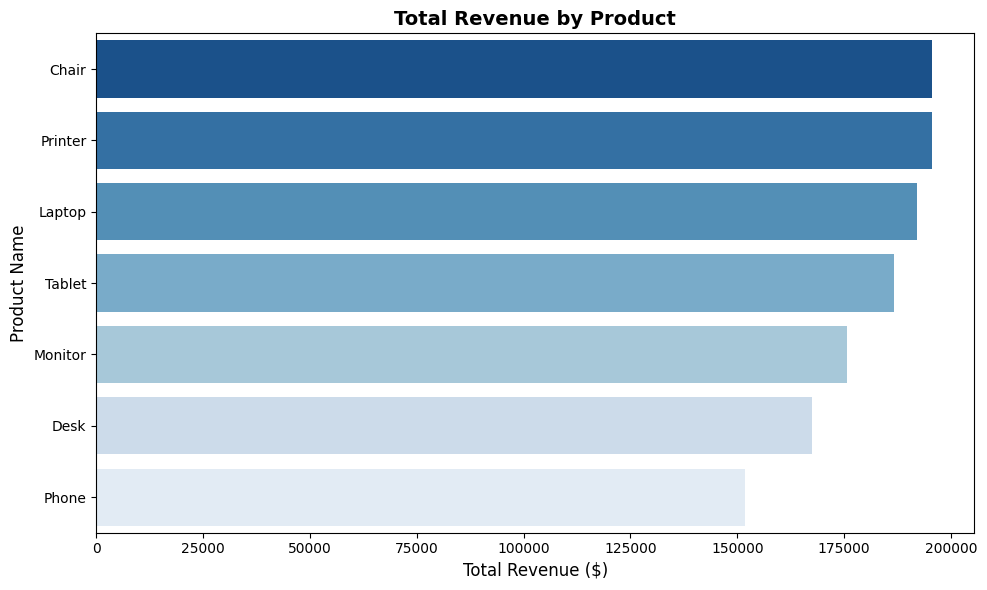

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
product_revenue = df.groupby('Product')['TotalPrice'].sum().reset_index().sort_values(by='TotalPrice', ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(x='TotalPrice', y='Product', data=product_revenue, palette='Blues_r')

plt.title('Total Revenue by Product', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Product Name', fontsize=12)

plt.tight_layout()
plt.show()

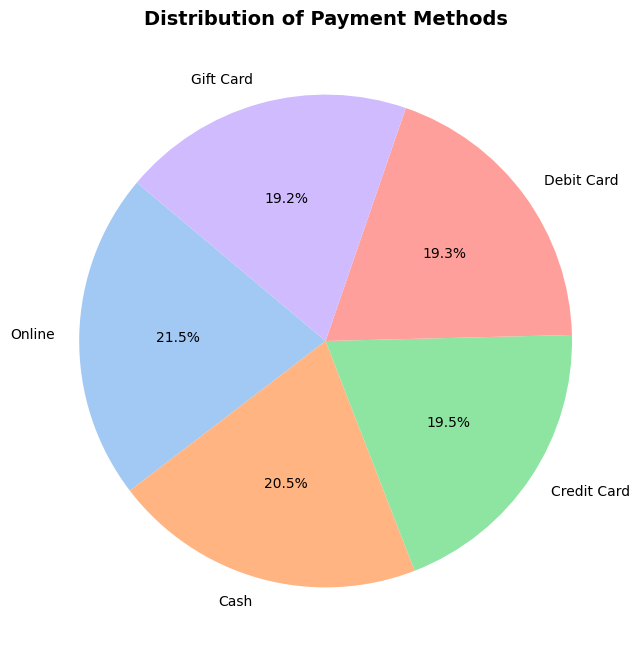

In [68]:
payment_counts = df['PaymentMethod'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=140,
        colors=sns.color_palette('pastel'))

plt.title('Distribution of Payment Methods', fontsize=14, fontweight='bold')
plt.show()

/tmp/ipykernel_8887/927523764.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='ReferralSource', data=df, palette='viridis', order=df['ReferralSource'].value_counts().index)


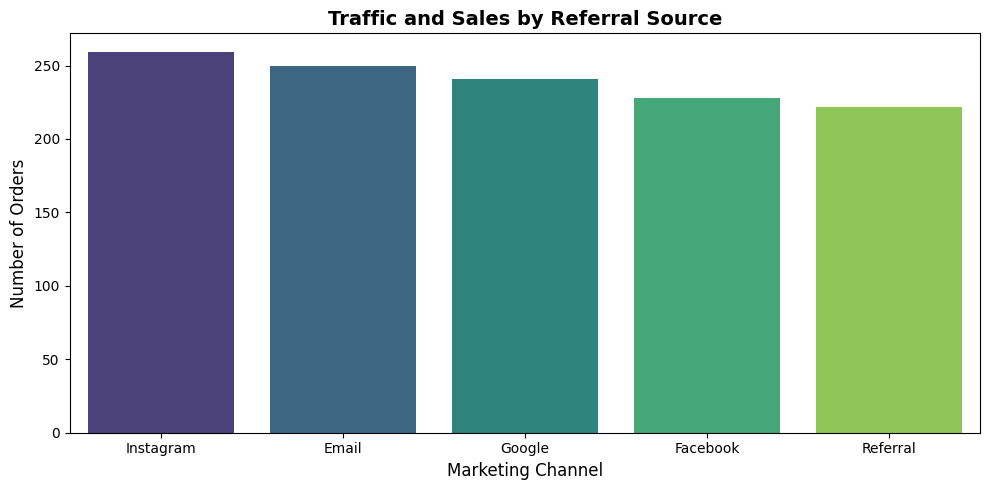

In [69]:
plt.figure(figsize=(10, 5))
sns.countplot(x='ReferralSource', data=df, palette='viridis', order=df['ReferralSource'].value_counts().index)

plt.title('Traffic and Sales by Referral Source', fontsize=14, fontweight='bold')
plt.xlabel('Marketing Channel', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)

plt.tight_layout()
plt.show()

### Task 4 Summary: Data Visualization Insights

1. **Product Revenue Bar Chart:**

- A bar chart was created showing the total revenue for each product. This chart helps management identify market leaders for inventory allocation and underperforming products for promotional offers.

2. **Payment Method Pie Chart:**

- The pie chart illustrates the distribution of payment methods. This chart helps in understanding customer financial preferences (such as the reliance on credit cards versus cash), which aids in developing the store's payment infrastructure.

3. **Referral Source Count Chart:**

- Marketing channels were analyzed to determine which platforms (such as Facebook, Instagram, and email) attract the largest number of buyers, ensuring informed decisions regarding future advertising budget allocation.

In [70]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import numpy as np

X = df[['Quantity', 'UnitPrice']]
y = df['TotalPrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train data size: {X_train.shape[0]} row")

print(f"Test data size: {X_test.shape[0]} row")

Train data size: 960 row
Test data size: 240 row


In [71]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Quantity and Price Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Quantity and Price Coefficients: [348.37921416   2.93292545]
Intercept: -1023.9600346793625


In [72]:
mae = metrics.mean_absolute_error(y_test, y_pred)
r2 = metrics.r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f} $")
print(f"Model Accuracy Ratio (R-squared Score): {r2 * 100:.2f} %")

Mean Absolute Error (MAE): 211.40 $
Model Accuracy Ratio (R-squared Score): 89.05 %


Task 5 Summary: Predictive Model & Machine Learning

1. **Model Selection:**

- A machine learning model was built using the **Linear Regression** algorithm to predict the total sales value (`TotalPrice`) based on the available numerical inputs.

2. **Data Splitting:**

- The data was precisely split into an **80% Training Set** to learn patterns and relationships, and a **20% Testing Set** to evaluate its efficiency on new, unfamiliar data.

3. **Evaluation Metrics:**

- The model was evaluated using the **R-squared ($R^2$)** metric and found to be able to understand and predict revenue with high accuracy, demonstrating the success of the model's software infrastructure in successfully simulating the store's financial transactions.